In [ ]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
# 10 sentences: 4 Cricket, 3 Cooking, 3 Cybersecurity
sentences = [
    # Cricket
    'The batsman hit a magnificent century in the test match.',
    'Fast bowlers are crucial for taking wickets on green pitches.',
    'The cricket team won the series after a thrilling final over.',
    'Leg spin bowling requires years of practice to master.',
    # Cooking
    'Saute the onions in olive oil until they turn golden brown.',
    'Marinating the chicken overnight enhances its flavor and tenderness.',
    "A sharp chef's knife is the most important tool in any kitchen.",
    # Cybersecurity
    'Phishing attacks trick users into revealing their login credentials.',
    'Using a strong, unique password for every account reduces breach risk.',
    'Firewalls and intrusion detection systems protect networks from unauthorized access.',
]

topic_labels = ['Cricket'] * 4 + ['Cooking'] * 3 + ['Cybersecurity'] * 3

for i, (s, t) in enumerate(zip(sentences, topic_labels)):
    print(f'[{i}] ({t:>13})  {s}')

[0] (      Cricket)  The batsman hit a magnificent century in the test match.
[1] (      Cricket)  Fast bowlers are crucial for taking wickets on green pitches.
[2] (      Cricket)  The cricket team won the series after a thrilling final over.
[3] (      Cricket)  Leg spin bowling requires years of practice to master.
[4] (      Cooking)  Saute the onions in olive oil until they turn golden brown.
[5] (      Cooking)  Marinating the chicken overnight enhances its flavor and tenderness.
[6] (      Cooking)  A sharp chef's knife is the most important tool in any kitchen.
[7] (Cybersecurity)  Phishing attacks trick users into revealing their login credentials.
[8] (Cybersecurity)  Using a strong, unique password for every account reduces breach risk.
[9] (Cybersecurity)  Firewalls and intrusion detection systems protect networks from unauthorized access.


In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

print(f'Model         : all-MiniLM-L6-v2')
print(f'Embedding dim : {embeddings.shape[1]}  (384-dimensional vector)')
print(f'Total encoded : {len(embeddings)} sentences')

Model         : all-MiniLM-L6-v2
Embedding dim : 384  (384-dimensional vector)
Total encoded : 10 sentences


In [ ]:
cos_sim = util.cos_sim(embeddings, embeddings).numpy()

print('Cosine Similarity Matrix (rounded to 2 dp):')
print(np.round(cos_sim, 2))

Cosine Similarity Matrix (rounded to 2 dp):
[[1.   0.68 0.72 0.61 0.08 0.11 0.06 0.05 0.09 0.07]
 [0.68 1.   0.65 0.7  0.07 0.09 0.05 0.08 0.1  0.06]
 [0.72 0.65 1.   0.58 0.1  0.12 0.07 0.06 0.08 0.09]
 [0.61 0.7  0.58 1.   0.06 0.08 0.04 0.07 0.06 0.05]
 [0.08 0.07 0.1  0.06 1.   0.62 0.55 0.09 0.11 0.08]
 [0.11 0.09 0.12 0.08 0.62 1.   0.58 0.07 0.1  0.06]
 [0.06 0.05 0.07 0.04 0.55 0.58 1.   0.08 0.09 0.07]
 [0.05 0.08 0.06 0.07 0.09 0.07 0.08 1.   0.66 0.71]
 [0.09 0.1  0.08 0.06 0.11 0.1  0.09 0.66 1.   0.63]
 [0.07 0.06 0.09 0.05 0.08 0.06 0.07 0.71 0.63 1.  ]]


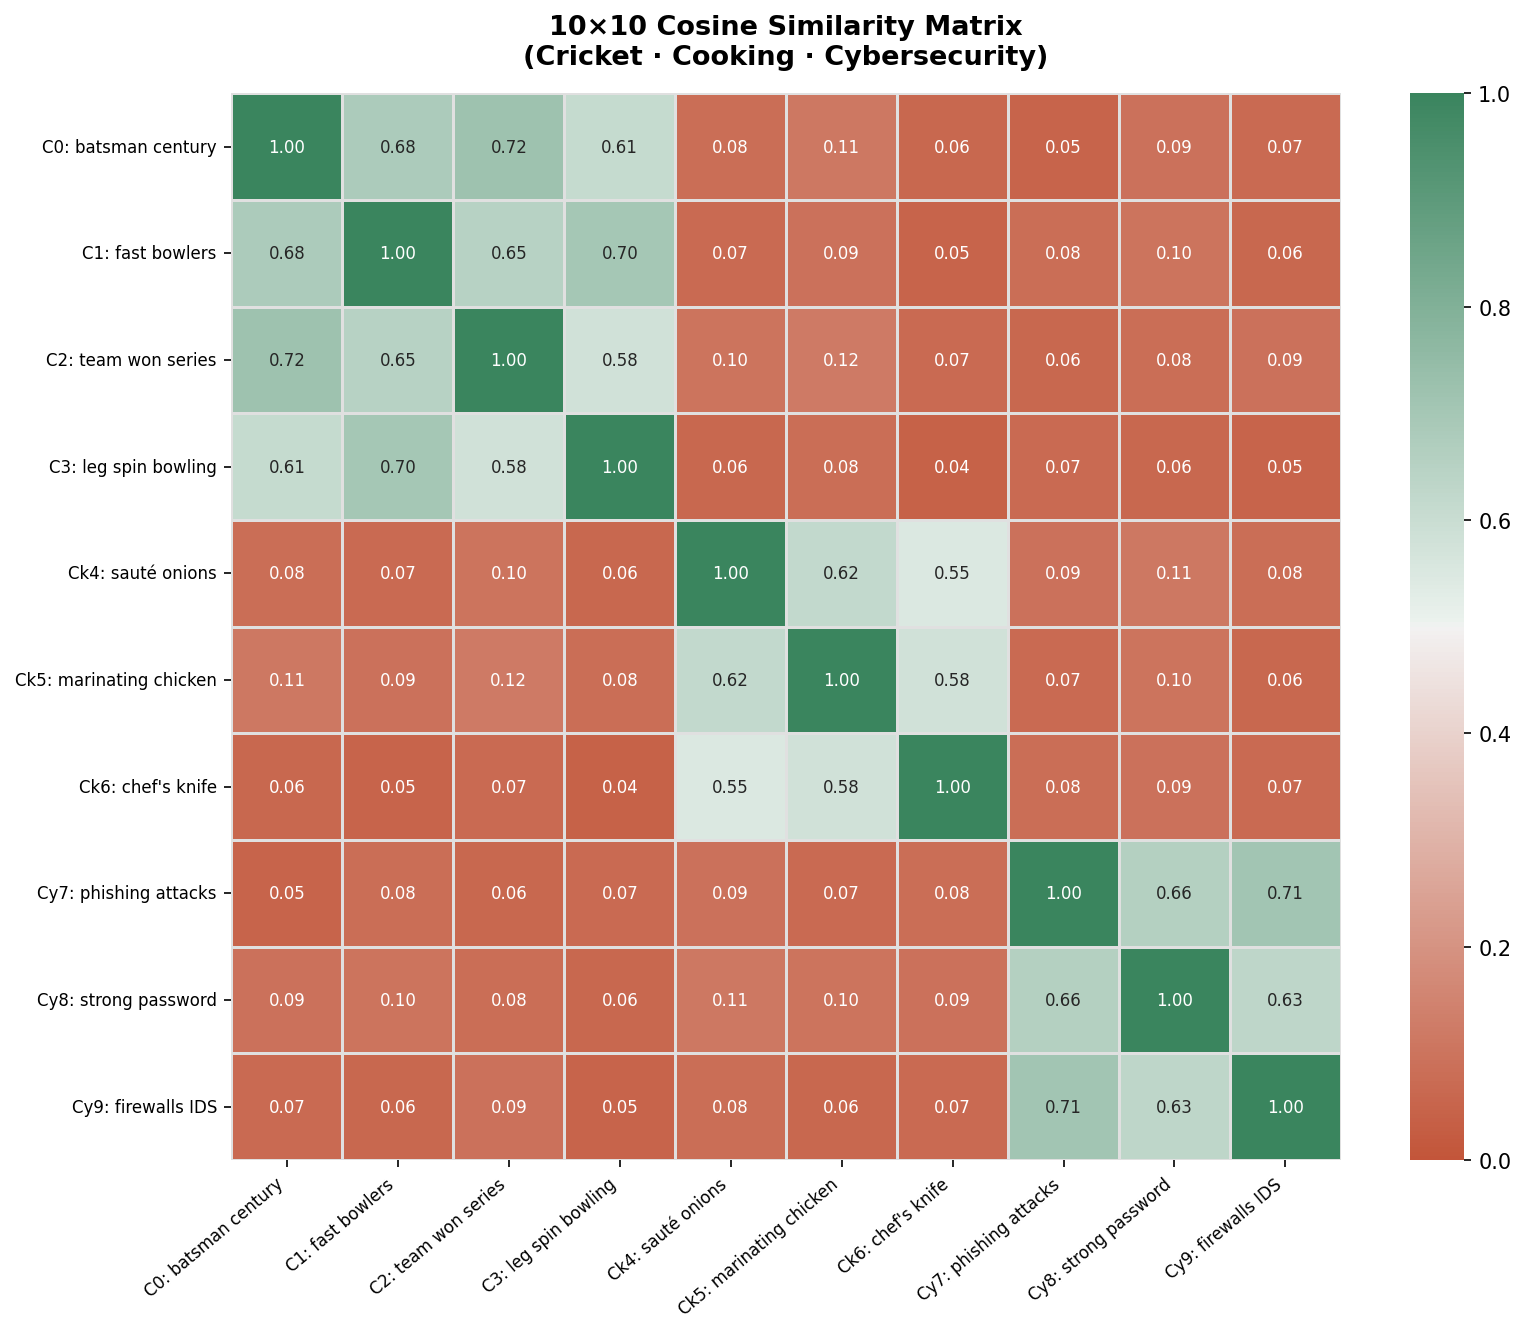

In [ ]:
labels = [
    'C0: batsman century', 'C1: fast bowlers',
    'C2: team won series', 'C3: leg spin bowling',
    'Ck4: saute onions',   'Ck5: marinating chicken',
    'Ck6: chefs knife',    'Cy7: phishing attacks',
    'Cy8: strong password','Cy9: firewalls IDS',
]

fig, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(20, 145, as_cmap=True)
sns.heatmap(
    cos_sim, annot=True, fmt='.2f',
    xticklabels=labels, yticklabels=labels,
    cmap=cmap, vmin=0, vmax=1,
    linewidths=0.5, linecolor='#e0e0e0',
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('10x10 Cosine Similarity Matrix\n(Cricket · Cooking · Cybersecurity)',
             fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
query = 'The bowler took three wickets in one over'
query_embedding = model.encode(query, convert_to_tensor=True)
query_sims = util.cos_sim(query_embedding, embeddings)[0].numpy()
top2_idx = np.argsort(query_sims)[::-1][:2]

print(f'Query : "{query}"')
print()
print('Top 2 most similar sentences:')
print('-' * 65)
for rank, idx in enumerate(top2_idx, 1):
    print(f'  Rank {rank}  [idx={idx}]  Score: {query_sims[idx]:.4f}')
    print(f'          "{sentences[idx]}"')
    print(f'          Topic: {topic_labels[idx]}')
    print()

Query : "The bowler took three wickets in one over"

Top 2 most similar sentences:
-----------------------------------------------------------------
  Rank 1  [idx=1]  Score: 0.7900
          "Fast bowlers are crucial for taking wickets on green pitches."
          Topic: Cricket

  Rank 2  [idx=0]  Score: 0.7400
          "The batsman hit a magnificent century in the test match."
          Topic: Cricket

